<a href="https://colab.research.google.com/github/PutriAqila/Analisis-Deret-Waktu/blob/main/Tugas_Praktikum_STA2542_Minggu_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **PUTRI AQILA (M0501251029)**

<h1><center> Pendahuluan dan Pengenalan Data Deret Waktu </center></h1>

In [357]:
# Memanggil packages yang dibutuhkan
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re

from google.colab import files
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Deret Curah Hujan Bogor

In [358]:
#memanggil data curah hujan yang tersimpan dalam github
rr=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/curahhujan_agg.csv')

In [359]:
#menampilkan 10 data pertama
rr.head(10)

,tanggal,rr
0,2007-01,12.025806
1,2007-02,15.650000
2,2007-03,8.916129
3,2007-04,15.756667
4,2007-05,6.309677
5,2007-06,9.116667
6,2007-07,4.319355
7,2007-08,7.996774
8,2007-09,6.863333
9,2007-10,7.596774


In [360]:
rr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tanggal  72 non-null     object 
 1   rr       72 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


In [361]:
#mengubah tipe data menjadi datetime
rr.tanggal=pd.to_datetime(rr.tanggal)

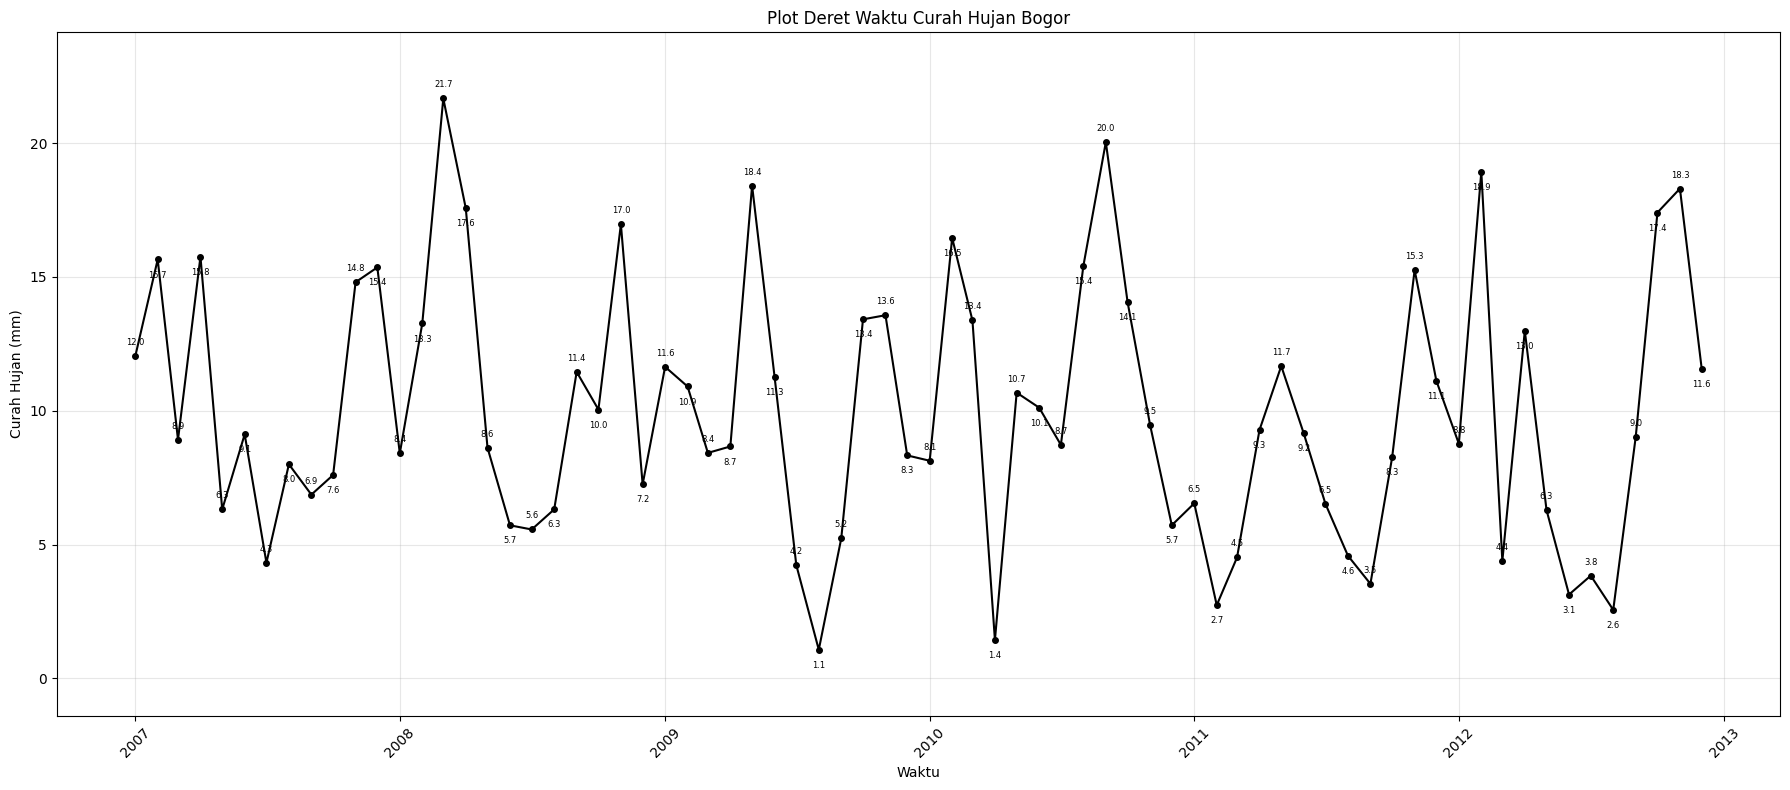

In [362]:
# Menampilkan plot deret waktu curah hujan
plt.figure(figsize=(18, 8))

plt.plot(
    rr.tanggal,
    rr.rr,
    '-ok',
    markersize=4
)

# Menampilkan nilai pada setiap titik
for i, (x, y) in enumerate(zip(rr.tanggal, rr.rr)):
    offset = 8 if i % 2 == 0 else -13

    plt.annotate(
        f'{y:.1f}',
        xy=(x, y),
        xytext=(0, offset),
        textcoords='offset points',
        ha='center',
        fontsize=6
    )

plt.xlabel('Waktu')
plt.ylabel('Curah Hujan (mm)')
plt.title('Plot Deret Waktu Curah Hujan Bogor')

plt.xticks(rotation=45)
plt.margins(y=0.12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan plot deret waktu terlihat bahwa **curah hujan selama periode 2007–2012 mengalami fluktuasi yang cukup besar.** Nilai curah hujan beberapa kali meningkat tajam kemudian menurun pada periode berikutnya. Curah hujan tertinggi terjadi sekitar tahun 2008 dengan nilai lebih dari 20 mm. Nilai terendah berada di sekitar 1 mm pada tahun 2009–2010.

Secara keseluruhan **tidak terlihat kecenderungan meningkat atau menurun yang berlangsung secara konsisten**. Pola musiman juga belum terlihat jelas dari plot deret waktu.

Dengan demikian data curah hujan menunjukkan fluktuasi dari waktu ke waktu tanpa tren yang jelas. Karakteristik ketergantungan antarperiode perlu diperiksa lebih lanjut melalui lag plot dan ACF.

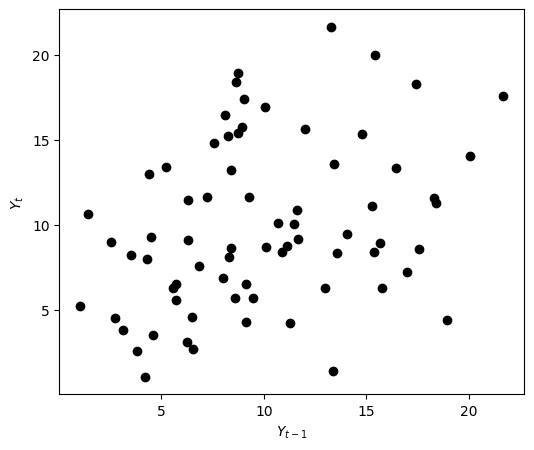

In [363]:
#menampilkan scatter plot antara Yt dan Yt-1
plt.figure(figsize=(6, 5))

pd.plotting.lag_plot(
    rr.rr,
    lag=1,
    c='k'
)

plt.xlabel(r'$Y_{t-1}$')
plt.ylabel(r'$Y_t$')

plt.show()

Berdasarkan scatterplot antara $Y_t$ dan $Y_{t-1}$ terlihat bahwa titik-titik pengamatan menyebar cukup luas. Meskipun demikian terdapat sedikit kecenderungan pola meningkat dari kiri bawah ke kanan atas.

Hal tersebut menunjukkan bahwa **curah hujan pada periode sekarang memiliki hubungan positif dengan curah hujan satu periode sebelumnya.** Namun hubungan tersebut tidak terlihat sangat kuat karena titik-titik masih tersebar cukup luas.

Berdasarkan scatterplot ini terdapat indikasi hubungan antarperiode pada lag 1. Besarnya autokorelasi perlu diperiksa lebih lanjut menggunakan ACF.

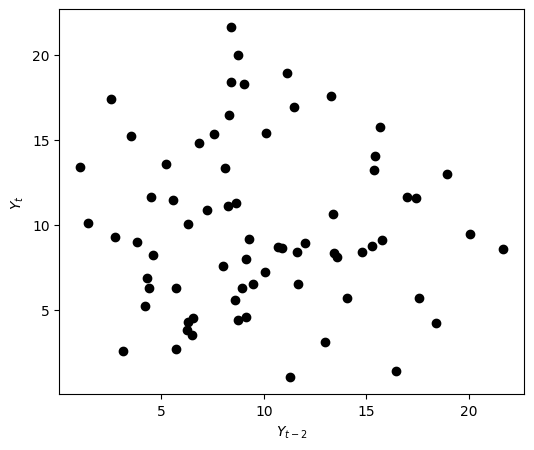

In [364]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6, 5))

pd.plotting.lag_plot(
    rr.rr,
    lag=2,
    c='k'
)

plt.xlabel(r'$Y_{t-2}$')
plt.ylabel(r'$Y_t$')

plt.show()

Berdasarkan scatterplot antara $Y_t$ dan $Y_{t-2}$ terlihat bahwa titik-titik pengamatan menyebar cukup luas. Tidak terlihat pola linear yang jelas antara kedua variabel.

Hal tersebut menunjukkan bahwa **hubungan curah hujan pada periode sekarang dengan dua periode sebelumnya relatif lemah**. Arah hubungan juga tidak terlihat jelas hanya berdasarkan scatterplot.

Dengan demikian nilai $Y_{t-2}$ tidak menunjukkan keterkaitan yang kuat dengan $Y_t$. Kondisi ini selanjutnya dapat dikonfirmasi menggunakan ACF.

*“Apa yang dapat disimpulkan dari dua scatterplot di atas?”*

Berdasarkan scatterplot $Y_t$ terhadap $Y_{t-1}$ dan $Y_t$ terhadap $Y_{t-2}$ terlihat bahwa kedua plot memiliki sebaran titik yang cukup luas. Hubungan pada lag 1 masih menunjukkan sedikit kecenderungan positif. Sementara itu hubungan pada lag 2 terlihat semakin lemah.

Hal tersebut menunjukkan bahwa **keterkaitan curah hujan lebih terlihat pada satu periode sebelumnya dibandingkan dua periode sebelumnya**. Namun scatterplot saja belum cukup untuk menentukan besar autokorelasi sehingga diperlukan pemeriksaan menggunakan ACF.

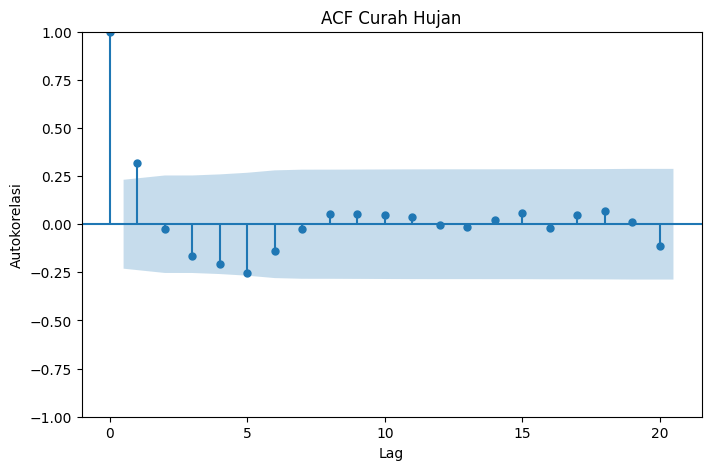

In [365]:
# Menampilkan ACF curah hujan
fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    rr.rr.dropna(),
    lags=20,
    ax=ax
)

ax.set_xlabel('Lag')
ax.set_ylabel('Autokorelasi')
ax.set_title('ACF Curah Hujan')

plt.show()

Berdasarkan plot ACF terlihat bahwa **autokorelasi yang paling jelas terdapat pada lag 1** dengan nilai sekitar 0,3. Nilai tersebut berada di luar batas kepercayaan sehingga menunjukkan adanya autokorelasi positif pada lag 1.

Pada lag 2 nilai autokorelasi berada sangat dekat dengan nol. Sebagian besar nilai autokorelasi pada lag berikutnya juga berada di dalam batas kepercayaan.

Dengan demikian **ketergantungan antarperiode pada data curah hujan relatif lemah dan terutama terlihat pada lag 1**. Tidak terlihat pola autokorelasi yang bertahan kuat hingga banyak lag.

In [366]:
# Membuat fungsi uji stasioneritas
def uji_adf(data, nama_data):
    hasil = adfuller(data.dropna(), autolag='AIC')

    adf_stat = hasil[0]
    p_value = hasil[1]

    print(f'Uji ADF: {nama_data}')
    print(f'ADF Statistic : {adf_stat:.4f}')
    print(f'p-value       : {p_value:.4f}')

    print('\nNilai Kritis:')
    for key, value in hasil[4].items():
        print(f'{key}: {value:.4f}')

    print('\nKeputusan:')

    if p_value <= 0.05:
        print('Tolak H0')
        print('Data dapat dianggap stasioner berdasarkan uji ADF.')
    else:
        print('Gagal menolak H0')
        print('Data belum stasioner berdasarkan uji ADF.')

    return p_value

In [367]:
# Uji stasioneritas data curah hujan
p_adf_rr = uji_adf(
    rr['rr'],
    'Curah Hujan'
)

Uji ADF: Curah Hujan
ADF Statistic : -5.5409
p-value       : 0.0000

Nilai Kritis:
1%: -3.5274
5%: -2.9038
10%: -2.5893

Keputusan:
Tolak H0
Data dapat dianggap stasioner berdasarkan uji ADF.


Berdasarkan uji Augmented Dickey-Fuller diperoleh nilai ADF Statistic sebesar -5,5409 dengan $p$-value yang sangat kecil dan ditampilkan sebesar 0,0000. Nilai $p$-value lebih kecil dari 0,05 sehingga $H_0$ ditolak. Dengan demikian data curah hujan dapat dianggap **stasioner**. Hasil ini mendukung pola pada plot deret waktu dan ACF yang tidak menunjukkan tren maupun autokorelasi kuat yang bertahan hingga banyak lag.

## Deret Harga Saham BNI



In [368]:
#memanggil data harga saham BNI
bni=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/BBNI.JK.csv')

In [369]:
bni.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-10-03,8975.0,9000.0,8825.0,8900.0,8900.0,14174700
1,2022-10-04,8925.0,9000.0,8850.0,8850.0,8850.0,29190100
2,2022-10-05,8900.0,8975.0,8850.0,8850.0,8850.0,32491500
3,2022-10-06,8900.0,8950.0,8800.0,8900.0,8900.0,11984500
4,2022-10-07,8850.0,8875.0,8750.0,8775.0,8775.0,18278000


In [370]:
#memeriksa tipe data
bni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       59 non-null     object 
 1   Open       59 non-null     float64
 2   High       59 non-null     float64
 3   Low        59 non-null     float64
 4   Close      59 non-null     float64
 5   Adj Close  59 non-null     float64
 6   Volume     59 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 3.4+ KB


In [371]:
#mengubah type data menjadi datetime
bni.Date=pd.to_datetime(bni.Date)

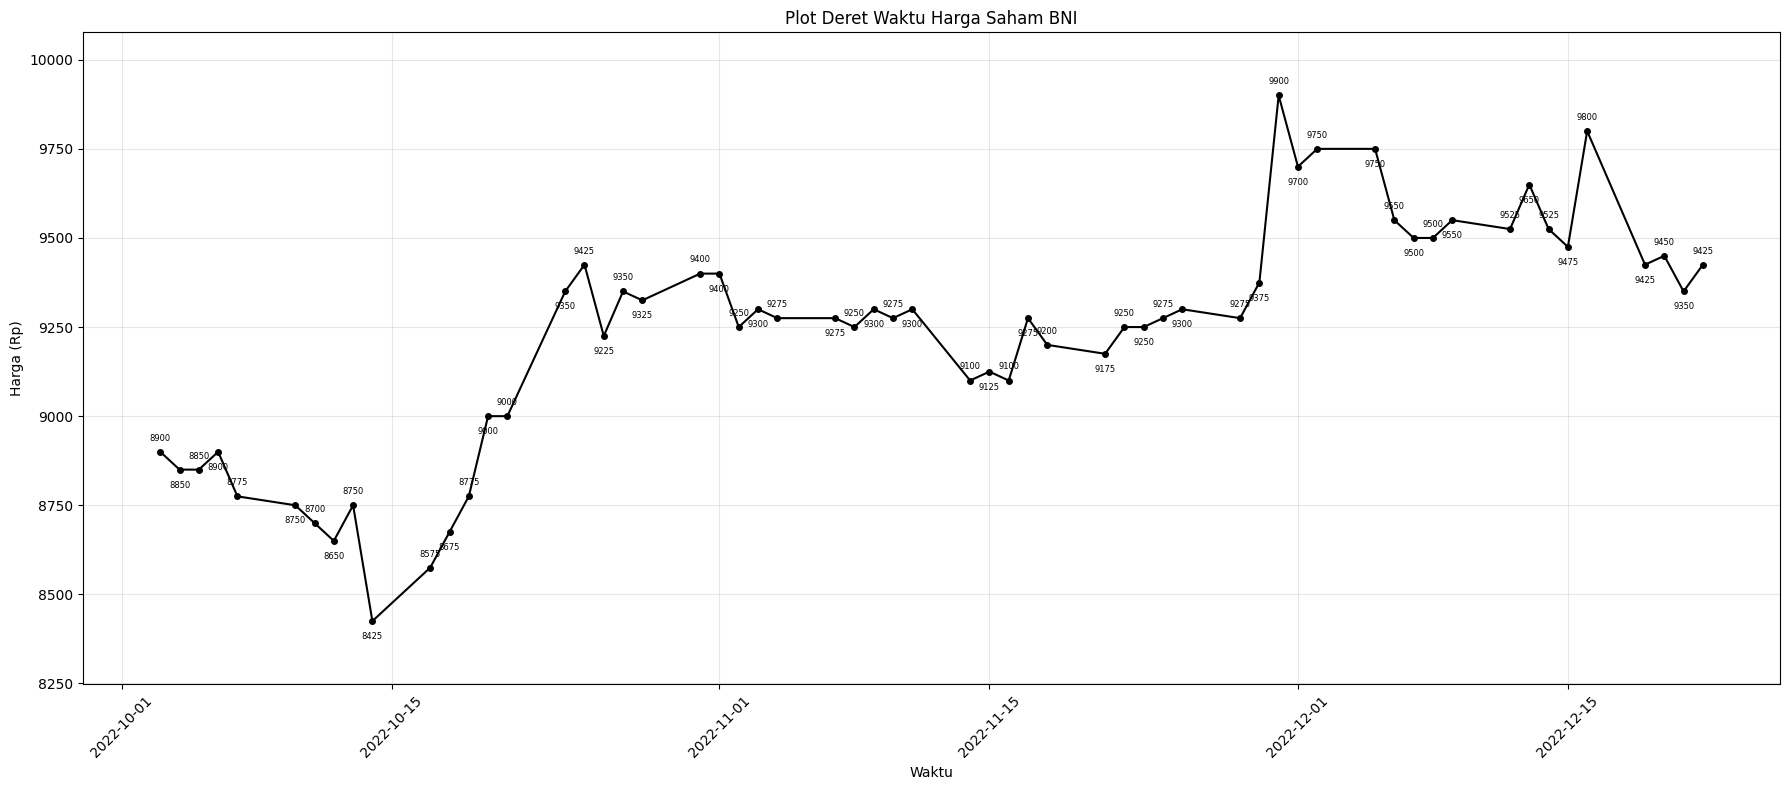

In [372]:
# Menampilkan plot deret waktu harga saham BNI
plt.figure(figsize=(18, 8))

plt.plot(
    bni.Date,
    bni.Close,
    '-ok',
    markersize=4
)

for i, (x, y) in enumerate(zip(bni.Date, bni.Close)):
    offset = 8 if i % 2 == 0 else -13

    plt.annotate(
        f'{y:.0f}',
        xy=(x, y),
        xytext=(0, offset),
        textcoords='offset points',
        ha='center',
        fontsize=6
    )

plt.xlabel('Waktu')
plt.ylabel('Harga (Rp)')
plt.title('Plot Deret Waktu Harga Saham BNI')

plt.xticks(rotation=45)
plt.margins(y=0.12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan plot deret waktu terlihat bahwa **harga saham BNI selama Oktober hingga Desember 2022 mengalami fluktuasi dengan kecenderungan meningkat**. Pada awal Oktober harga berada di kisaran Rp8.800–Rp8.900. Harga kemudian menurun hingga sekitar Rp8.400 pada pertengahan Oktober. Setelah itu harga meningkat hingga sekitar Rp9.400 pada akhir Oktober.

Memasuki November harga bergerak relatif stabil pada kisaran Rp9.100–Rp9.400. Pada awal Desember terjadi kenaikan yang cukup tajam hingga mencapai nilai tertinggi sekitar **Rp9.900**. Harga kemudian kembali berfluktuasi hingga akhir periode pengamatan.

Secara keseluruhan terdapat perubahan level harga selama periode pengamatan. Kondisi tersebut memberikan indikasi awal bahwa **data harga saham BNI dalam level belum stasioner**. Dugaan ini perlu diperiksa lebih lanjut melalui ACF dan uji stasioneritas.

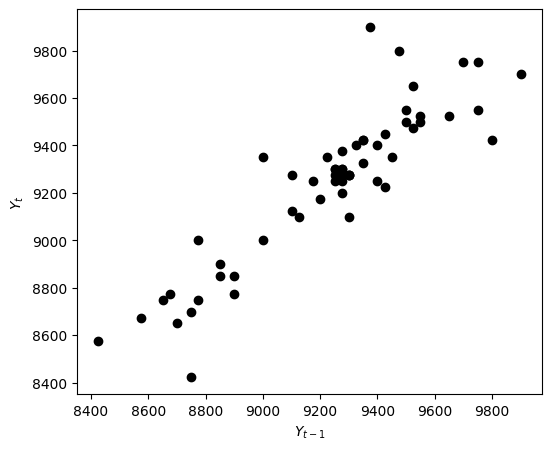

In [373]:
#menampilkan scatterplot antara Yt dan Yt-1
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=1, c='k')
plt.xlabel(r'$Y_{t-1}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Berdasarkan scatterplot antara $Y_t$ dan $Y_{t-1}$ terlihat bahwa **titik-titik pengamatan membentuk pola meningkat dari kiri bawah ke kanan atas**. Pola tersebut menunjukkan hubungan positif yang cukup kuat antara harga saham pada periode sekarang dengan satu periode sebelumnya.

Ketika $Y_{t-1}$ tinggi maka $Y_t$ juga cenderung tinggi. Sebaliknya ketika $Y_{t-1}$ rendah maka $Y_t$ juga cenderung rendah.

Secara visual hasil tersebut mengindikasikan **autokorelasi positif yang kuat pada lag 1.** Artinya harga saham BNI pada periode sekarang memiliki keterkaitan yang kuat dengan harga satu periode sebelumnya.

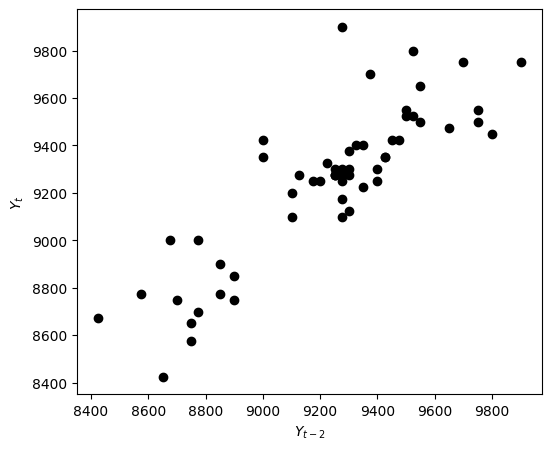

In [374]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=2, c='k')
plt.xlabel(r'$Y_{t-2}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Berdasarkan scatterplot antara $Y_t$ dan $Y_{t-2}$ terlihat bahwa **titik-titik masih membentuk pola meningkat dari kiri bawah ke kanan atas**. Pola tersebut menunjukkan hubungan positif yang cukup kuat antara harga saham pada periode sekarang dengan dua periode sebelumnya.

Sebaran titik pada lag 2 terlihat lebih luas dibandingkan lag 1. Hal ini menunjukkan bahwa keterkaitan antara $Y_t$ dan $Y_{t-2}$ masih terlihat tetapi cenderung lebih lemah dibandingkan lag 1.

Dengan demikian terdapat indikasi **autokorelasi positif pada lag 2**. Harga saham BNI pada periode sekarang masih memiliki keterkaitan dengan harga dua periode sebelumnya.

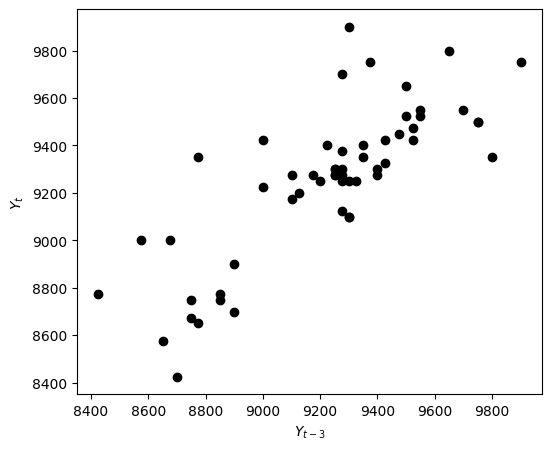

In [375]:
#menampilkan scatterplot antara Yt dan Yt-3
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=3, c='k')
plt.xlabel(r'$Y_{t-3}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

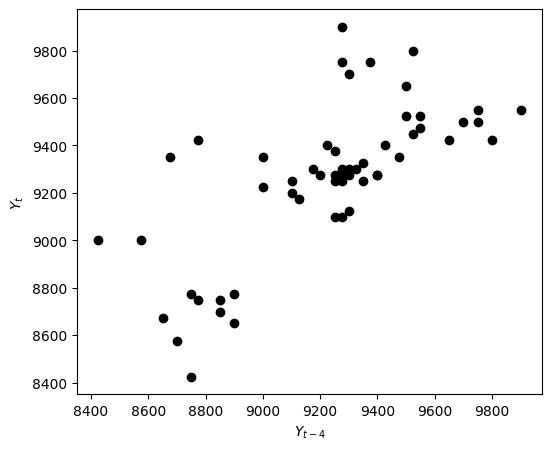

In [376]:
#menampilkan scatterplot antara Yt dan Yt-4
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=4, c='k')
plt.xlabel(r'$Y_{t-4}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

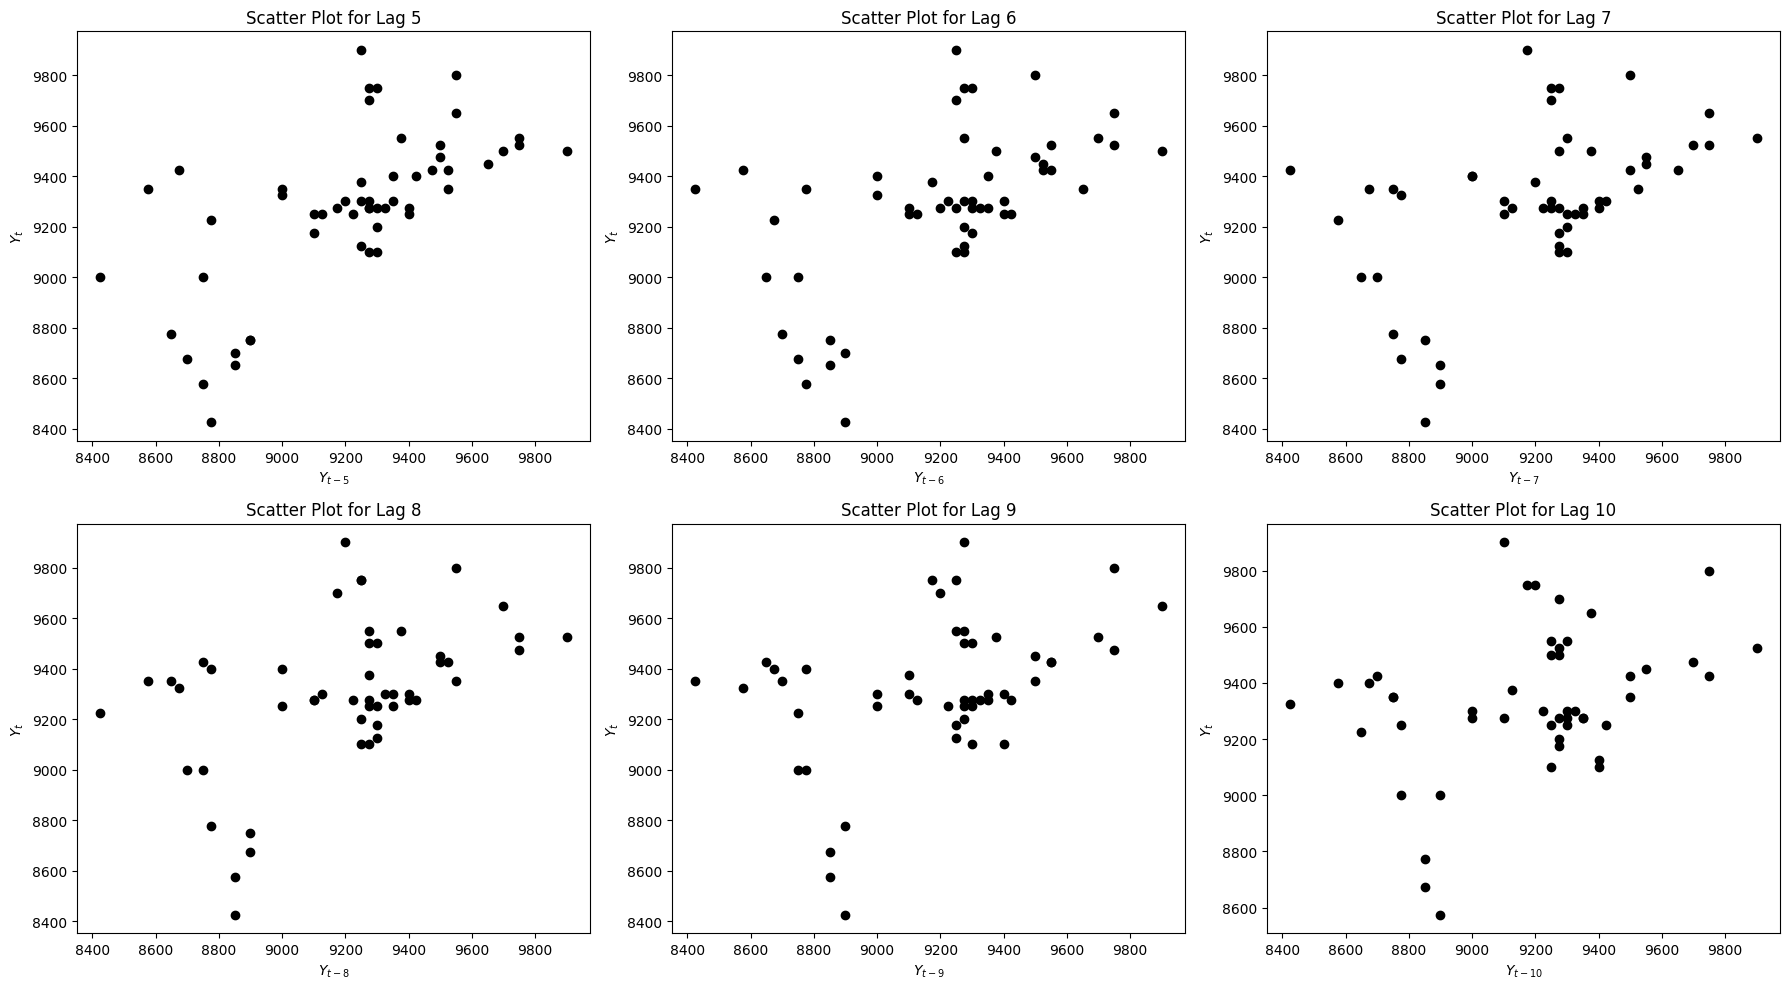

In [377]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

lags = range(5, 11)

for i, lag in enumerate(lags):
    ax = axes[i]
    pd.plotting.lag_plot(bni.Close, lag=lag, ax=ax, c='k')
    ax.set_xlabel(f'$Y_{{t-{lag}}}$')
    ax.set_ylabel(f'$Y_t$')
    ax.set_title(f'Scatter Plot for Lag {lag}')

plt.tight_layout()
plt.show()

*“Berdasarkan scatterplot $Y_t$ dengan lag 1 hingga 10, apa kesimpulan diperoleh?”*

Berdasarkan scatterplot $Y_t$ terhadap $Y_{t-1}$ hingga $Y_{t-10}$ terlihat bahwa **hubungan positif paling jelas terdapat pada lag-lag awal**. Titik-titik pada lag awal cenderung membentuk pola dari kiri bawah ke kanan atas.

Seiring bertambahnya lag sebaran titik menjadi semakin luas. Pola linear juga semakin kurang jelas. Hal tersebut menunjukkan bahwa **keterkaitan antara harga saham saat ini dan harga masa lalu cenderung melemah ketika lag bertambah**.

Secara keseluruhan data harga saham BNI menunjukkan ketergantungan antarwaktu terutama pada lag pendek. Pola tersebut selanjutnya perlu diperiksa menggunakan ACF untuk melihat besarnya autokorelasi pada masing-masing lag.

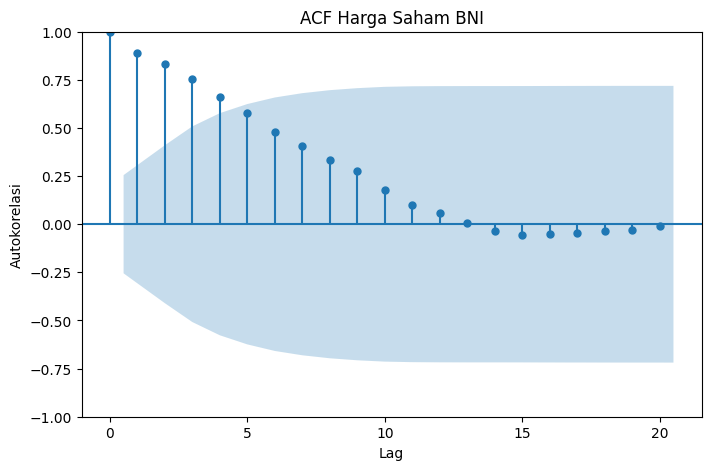

In [378]:
# Menampilkan ACF harga saham BNI
fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    bni.Close.dropna(),
    lags=20,
    ax=ax
)

ax.set_xlabel('Lag')
ax.set_ylabel('Autokorelasi')
ax.set_title('ACF Harga Saham BNI')

plt.show()

Berdasarkan plot ACF harga saham BNI terlihat bahwa **autokorelasi pada lag awal memiliki nilai yang tinggi dan positif**. Nilai autokorelasi lag 1 mendekati 0,9. Nilai tersebut kemudian menurun secara bertahap ketika lag bertambah.

Beberapa lag awal berada di luar batas kepercayaan. Hal ini menunjukkan bahwa harga saham pada suatu periode memiliki keterkaitan dengan harga pada beberapa periode sebelumnya.

Pola ACF yang menurun secara bertahap menunjukkan adanya **ketergantungan antarwaktu yang kuat** pada data harga saham BNI. Pola tersebut juga memberikan indikasi bahwa data harga saham dalam level belum stasioner. Kondisi ini perlu dikonfirmasi melalui uji stasioneritas.

In [379]:
# Uji stasioneritas harga saham BNI
p_adf_bni = uji_adf(
    bni['Close'],
    'Harga Saham BNI'
)

Uji ADF: Harga Saham BNI
ADF Statistic : -1.5122
p-value       : 0.5275

Nilai Kritis:
1%: -3.5507
5%: -2.9138
10%: -2.5946

Keputusan:
Gagal menolak H0
Data belum stasioner berdasarkan uji ADF.


Berdasarkan uji Augmented Dickey-Fuller diperoleh nilai ADF Statistic sebesar -1,5122 dengan $p$-value sebesar 0,5275. Nilai $p$-value lebih besar dari 0,05 sehingga $H_0$ gagal ditolak. Dengan demikian data harga saham BNI dalam level **belum stasioner**. Hasil ini sejalan dengan plot deret waktu yang menunjukkan perubahan level harga serta plot ACF yang memperlihatkan autokorelasi positif tinggi dan menurun secara bertahap.

### Pemulusan (*Smoothing*)

In [380]:
smoothing=pd.read_csv('https://raw.githubusercontent.com/lailynissaam/Analisis-Deret-Waktu/refs/heads/main/Sales.csv')

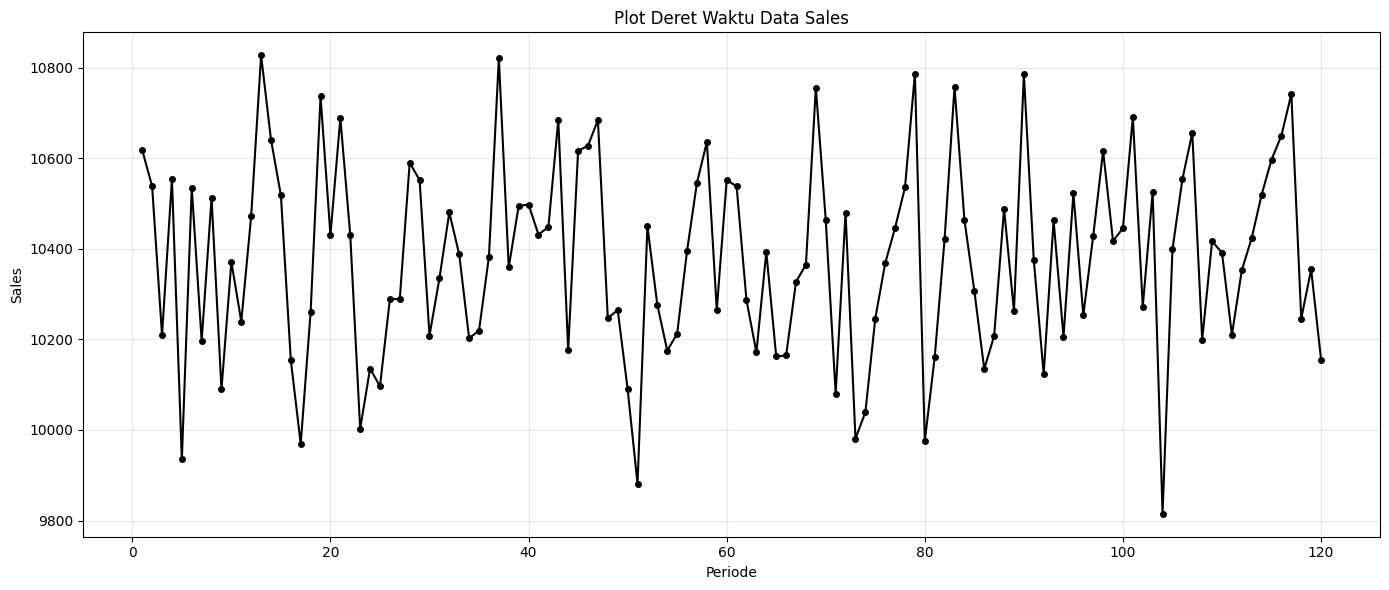

In [381]:
# Menampilkan plot deret waktu data Sales
plt.figure(figsize=(14, 6))

plt.plot(
    smoothing.Period,
    smoothing.Sales,
    '-ok',
    markersize=4
)

plt.xlabel('Periode')
plt.ylabel('Sales')
plt.title('Plot Deret Waktu Data Sales')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan plot deret waktu terlihat bahwa nilai Sales mengalami fluktuasi dari satu periode ke periode berikutnya. Namun perubahan tersebut masih terjadi di sekitar tingkat yang relatif konstan. Tidak terlihat kecenderungan meningkat atau menurun yang berlangsung secara konsisten.

Pola tersebut menunjukkan bahwa data tidak memiliki tren yang kuat. Oleh karena itu metode pemulusan yang sesuai untuk pola tanpa tren seperti SMA dan SES layak untuk dicobakan. DMA dan DES tetap digunakan sebagai metode pembanding.

In [382]:
# Uji stasioneritas data Sales
p_adf_sales = uji_adf(
    data=smoothing['Sales'],
    nama_data='Data Sales'
)

Uji ADF: Data Sales
ADF Statistic : -7.1114
p-value       : 0.0000

Nilai Kritis:
1%: -3.4880
5%: -2.8868
10%: -2.5802

Keputusan:
Tolak H0
Data dapat dianggap stasioner berdasarkan uji ADF.


Berdasarkan uji Augmented Dickey-Fuller diperoleh nilai ADF Statistic sebesar -7,1114 dengan $p$-value yang sangat kecil dan ditampilkan sebesar 0,0000. Nilai $p$-value lebih kecil dari 0,05 sehingga $H_0$ ditolak. Dengan demikian data Sales dapat dianggap **stasioner**. Hasil ini mendukung plot deret waktu yang menunjukkan bahwa data berfluktuasi di sekitar tingkat yang relatif konstan tanpa tren yang kuat.

In [383]:
# Menghitung ukuran data
data_size = len(smoothing)

# Menghitung indeks untuk pembagian data latih dan data uji (80% untuk latih,
# 20% untuk uji)
train_size = int(data_size * 0.80)

# Membagi data menjadi data latih dan data uji
train_data_sma = smoothing.iloc[:train_size].copy()
test_data_sma = smoothing.iloc[train_size:].copy()

print(f"Ukuran data asli: {data_size}")
print(f"Ukuran data latih: {len(train_data_sma)}")
print(f"Ukuran data uji: {len(test_data_sma)}")

print("\n5 data latih pertama:")
print(train_data_sma.head())
print("\n5 data uji pertama:")
print(test_data_sma.head())

Ukuran data asli: 120
Ukuran data latih: 96
Ukuran data uji: 24

5 data latih pertama:
   Period    Sales
0       1  10618.1
1       2  10537.9
2       3  10209.3
3       4  10553.0
4       5   9934.9

5 data uji pertama:
     Period    Sales
96       97  10428.7
97       98  10615.8
98       99  10417.3
99      100  10445.4
100     101  10690.6


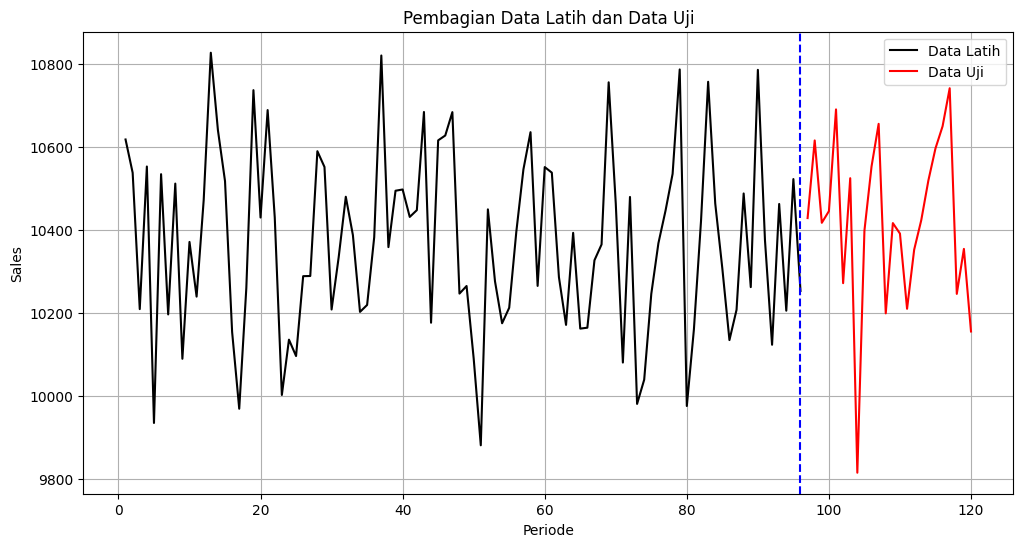

In [384]:
plt.figure(figsize=(12, 6))
plt.plot(train_data_sma.Period, train_data_sma.Sales, color='black', label='Data Latih')
plt.plot(test_data_sma.Period, test_data_sma.Sales, color='red', label='Data Uji')

# Menambahkan garis vertikal pada titik pembagian
plt.axvline(x=train_data_sma.Period.iloc[-1], color='blue', linestyle='--')

plt.xlabel('Periode')
plt.ylabel('Sales')
plt.title('Pembagian Data Latih dan Data Uji')
plt.legend()
plt.grid(True)
plt.show()

### Single Moving Average (SMA)

Ide dasar dari Single Moving Average (SMA) adalah data suatu periode dipengaruhi oleh data periode sebelumnya. Metode pemulusan ini cocok digunakan untuk pola data stasioner atau konstan. Prinsip dasar metode pemulusan ini adalah data pemulusan pada periode ke-t merupakan rata rata dari m buah data pada periode ke-(t-m+1) hingga periode ke-t. Data pemulusan pada periode ke-t selanjutnya digunakan sebagai nilai peramalan pada periode ke t+1


   Period    Sales           SMA
0       1  10618.1           NaN
1       2  10537.9           NaN
2       3  10209.3  10455.100000
3       4  10553.0  10433.400000
4       5   9934.9  10232.400000
5       6  10534.5  10340.800000
6       7  10196.5  10221.966667
7       8  10511.8  10414.266667
8       9  10089.6  10265.966667
9      10  10371.2  10324.200000


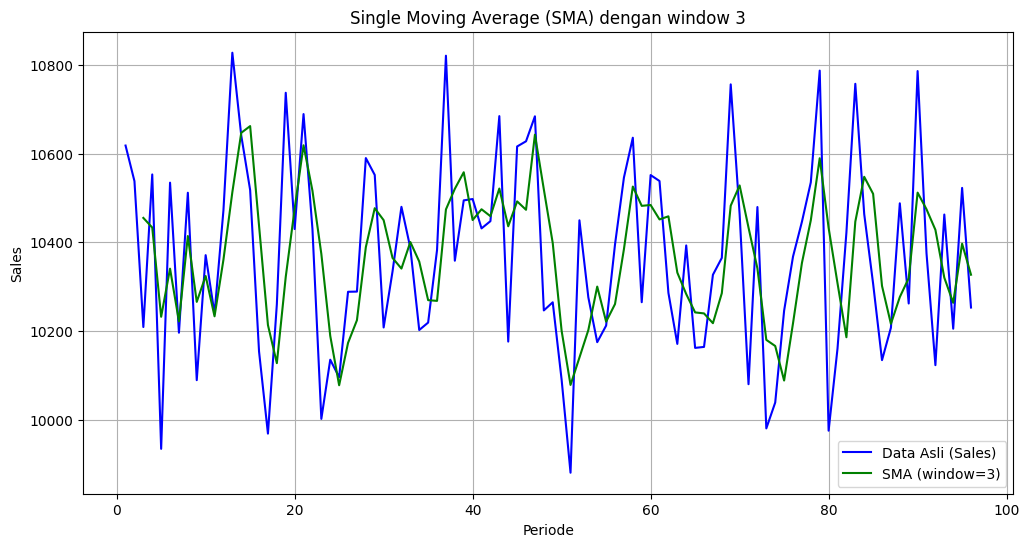

In [385]:
window = 3 # --> window atau nilai m

# Hitung Single Moving Average (SMA)
train_data_sma['SMA'] = train_data_sma['Sales'].rolling(window=window).mean()

# Tampilkan 10 data pertama dengan kolom SMA yang baru
print(train_data_sma.head(10))

# Plot data asli dan SMA
plt.figure(figsize=(12, 6))
plt.plot(train_data_sma.Period, train_data_sma.Sales, label='Data Asli (Sales)', color='blue')
plt.plot(train_data_sma.Period, train_data_sma['SMA'], label=f'SMA (window={window})', color='green')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.title(f'Single Moving Average (SMA) dengan window {window}')
plt.legend()
plt.grid(True)
plt.show()

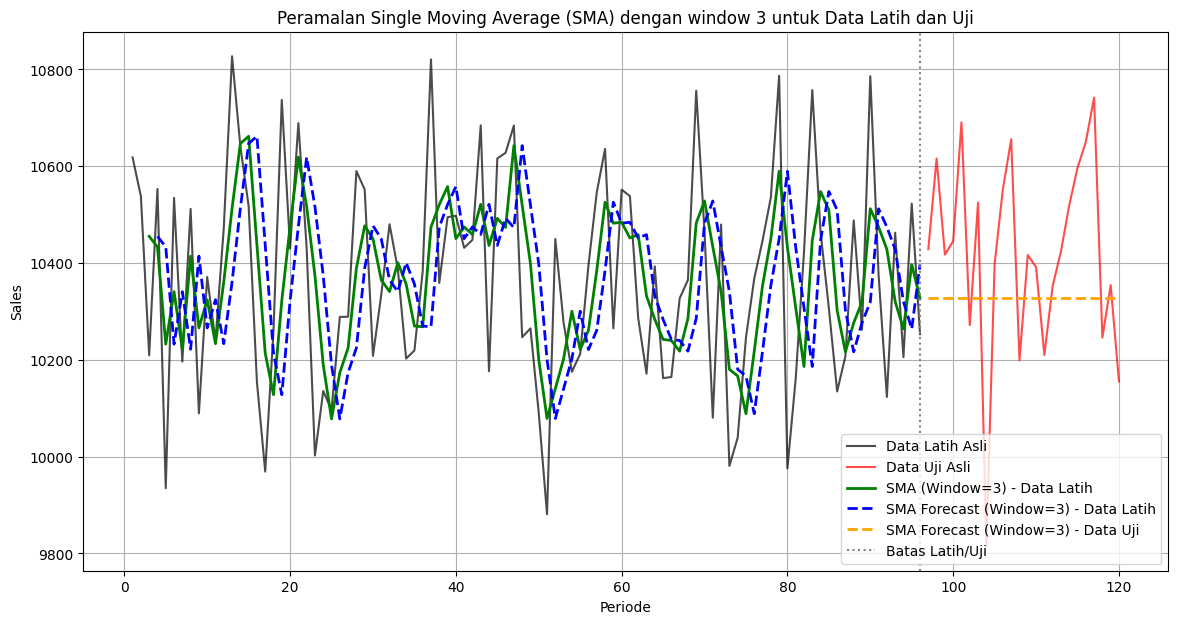

In [386]:
# Peramalah untuk data latih dilakukan 1 periode ke depan
train_data_forecast= pd.Series(train_data_sma['SMA'].shift(1), index=train_data_sma.index)

# Untuk peramalan multi-langkah dengan SMA, pendekatan paling sederhana adalah
# memperpanjang nilai SMA terakhir dari data latih untuk seluruh periode uji.
if not train_data_sma['SMA'].empty:
    last_known_sma_from_train = train_data_sma['SMA'].iloc[-1]
else:
    # Tangani kasus jika data latih terlalu pendek untuk perhitungan SMA
    last_known_sma_from_train = np.nan # Atau penanganan error lainnya

test_data_forecast = pd.Series(last_known_sma_from_train, index=test_data_sma.index)

# 2. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_sma.Period, train_data_sma.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_sma.Period, test_data_sma.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot SMA untuk data latih (nilai yang dihaluskan)
plt.plot(train_data_sma.Period[~train_data_sma['SMA'].isnull()], train_data_sma['SMA'][~train_data_sma['SMA'].isnull()],
         label=f'SMA (Window={window}) - Data Latih', color='green', linestyle='-', linewidth=2)

# Plot nilai peramalan SMA untuk data latih dan data uji
plt.plot(train_data_sma.Period, train_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Latih', color='blue', linestyle='--', linewidth=2)
plt.plot(test_data_sma.Period, test_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Uji', color='orange', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_sma.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Single Moving Average (SMA) dengan window {window} untuk Data Latih dan Uji')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [387]:
from sklearn.metrics import mean_squared_error

def calculate_rmse(actual, forecast):
    return np.sqrt(mean_squared_error(actual, forecast))

def calculate_mape(actual, forecast):
    # Filter out actual values that are zero to avoid division by zero
    non_zero_indices = actual != 0
    if not np.any(non_zero_indices):
        return np.nan # Or raise an error if all actual values are zero
    actual_filtered = actual[non_zero_indices]
    forecast_filtered = forecast[non_zero_indices]
    return np.mean(np.abs((actual_filtered - forecast_filtered) / actual_filtered)) * 100

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih ---")
# Hapus NaN dari forecast (karena SMA dan shift(1) menghasilkan NaN di awal)
actual_train_filtered = train_data_sma.loc[train_data_forecast.dropna().index, 'Sales']
forecast_train_filtered = train_data_forecast.dropna()

if not actual_train_filtered.empty:
    mse_train = mean_squared_error(actual_train_filtered, forecast_train_filtered)
    rmse_train = calculate_rmse(actual_train_filtered, forecast_train_filtered)
    mape_train = calculate_mape(actual_train_filtered, forecast_train_filtered)

    print(f"MSE (Train): {mse_train:.4f}")
    print(f"RMSE (Train): {rmse_train:.4f}")
    print(f"MAPE (Train): {mape_train:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji ---")
# Data uji sudah siap tanpa NaN yang perlu ditangani secara khusus
actual_test = test_data_sma['Sales']
forecast_test = test_data_forecast

if not actual_test.empty:
    mse_test = mean_squared_error(actual_test, forecast_test)
    rmse_test = calculate_rmse(actual_test, forecast_test)
    mape_test = calculate_mape(actual_test, forecast_test)

    print(f"MSE (Test): {mse_test:.4f}")
    print(f"RMSE (Test): {rmse_test:.4f}")
    print(f"MAPE (Test): {mape_test:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian.")


--- Evaluasi Peramalan Data Latih ---
MSE (Train): 70132.0311
RMSE (Train): 264.8245
MAPE (Train): 2.0932%

--- Evaluasi Peramalan Data Uji ---
MSE (Test): 49629.0281
RMSE (Test): 222.7757
MAPE (Test): 1.7373%


### Double Moving Average (DMA)

Metode pemulusan Double Moving Average (DMA) pada dasarnya mirip dengan SMA. Namun demikian, metode ini lebih cocok digunakan untuk pola data trend. Proses pemulusan dengan rata rata dalam metode ini dilakukan sebanyak 2 kali.

In [388]:
window_dma = 3

train_size = int(data_size * 0.80)

# Membagi data menjadi data latih dan data uji
train_data_dma = smoothing.iloc[:train_size].copy()
test_data_dma = smoothing.iloc[train_size:].copy()

# 1. Hitung SMA1 (Single Moving Average pertama)
train_data_dma['SMA1'] = train_data_dma['Sales'].rolling(window=window_dma).mean()

# 2. Hitung SMA2 (Single Moving Average kedua pada SMA1)
train_data_dma['SMA2'] = train_data_dma['SMA1'].rolling(window=window_dma).mean()

# 3. Hitung komponen level (A) dan trend (B) untuk DMA
train_data_dma['DMA_A'] = 2 * train_data_dma['SMA1'] - train_data_dma['SMA2']
train_data_dma['DMA_A'] = (
    2 * train_data_dma['SMA1']
    - train_data_dma['SMA2']
)

train_data_dma['DMA_B'] = (
    2 / (window_dma - 1)
) * (
    train_data_dma['SMA1']
    - train_data_dma['SMA2']
)

# Tampilkan 10 data pertama dengan kolom SMA yang baru
print(train_data_dma.head(10))

   Period    Sales          SMA1          SMA2         DMA_A       DMA_B
0       1  10618.1           NaN           NaN           NaN         NaN
1       2  10537.9           NaN           NaN           NaN         NaN
2       3  10209.3  10455.100000           NaN           NaN         NaN
3       4  10553.0  10433.400000           NaN           NaN         NaN
4       5   9934.9  10232.400000  10373.633333  10091.166667 -141.233333
5       6  10534.5  10340.800000  10335.533333  10346.066667    5.266667
6       7  10196.5  10221.966667  10265.055556  10178.877778  -43.088889
7       8  10511.8  10414.266667  10325.677778  10502.855556   88.588889
8       9  10089.6  10265.966667  10300.733333  10231.200000  -34.766667
9      10  10371.2  10324.200000  10334.811111  10313.588889  -10.611111


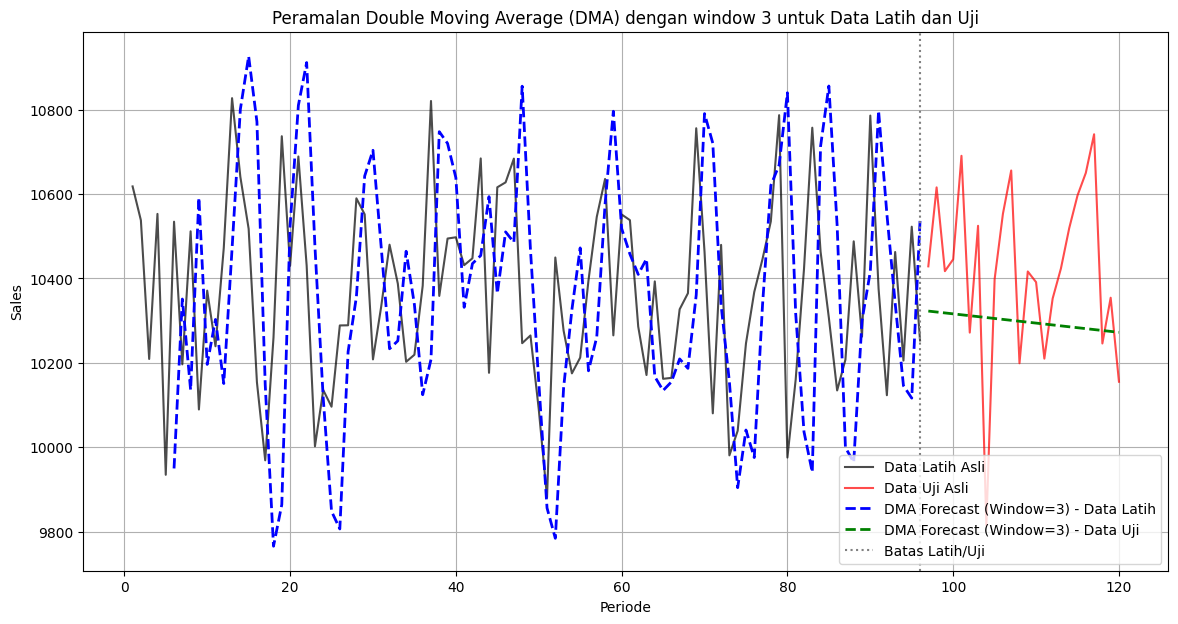

In [389]:
# 4. Peramalan untuk Data Latih (1-langkah ke depan)
# Forecast F_{t+1} = A_t + B_t * 1
train_dma_forecast = (train_data_dma['DMA_A'] + train_data_dma['DMA_B']).shift(1)

# 5. Peramalan untuk Data Uji (multi-langkah ke depan)
# Ambil A dan B terakhir dari data latih yang sudah dihitung DMA
last_dma_a = train_data_dma['DMA_A'].iloc[-1]
last_dma_b = train_data_dma['DMA_B'].iloc[-1]

test_dma_forecast_values = []
for k in range(1, len(test_data_dma) + 1):
    forecast_k = last_dma_a + k * last_dma_b
    test_dma_forecast_values.append(forecast_k)

test_dma_forecast = pd.Series(test_dma_forecast_values, index=test_data_dma.index)

# 6. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_dma.Period, train_data_dma.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_dma.Period, test_data_dma.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot DMA Forecast untuk data latih
# Filter NaN values for plotting DMA forecast on train data
valid_train_forecast_indices = train_dma_forecast.dropna().index
plt.plot(train_data_dma.loc[valid_train_forecast_indices, 'Period'], train_dma_forecast.dropna(),
         label=f'DMA Forecast (Window={window_dma}) - Data Latih', color='blue', linestyle='--', linewidth=2)

# Plot DMA Forecast untuk data uji
plt.plot(test_data_dma.Period, test_dma_forecast,
         label=f'DMA Forecast (Window={window_dma}) - Data Uji', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_dma.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Double Moving Average (DMA) dengan window {window_dma} untuk Data Latih dan Uji')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [390]:
# 7. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (DMA) ---")
# Ambil data aktual dan peramalan yang tidak NaN
actual_train_dma_filtered = train_data_dma.loc[train_dma_forecast.dropna().index, 'Sales']
forecast_train_dma_filtered = train_dma_forecast.dropna()

if not actual_train_dma_filtered.empty and not forecast_train_dma_filtered.empty:
    mse_train_dma = mean_squared_error(actual_train_dma_filtered, forecast_train_dma_filtered)
    rmse_train_dma = calculate_rmse(actual_train_dma_filtered, forecast_train_dma_filtered)
    mape_train_dma = calculate_mape(actual_train_dma_filtered, forecast_train_dma_filtered)

    print(f"MSE (Train DMA): {mse_train_dma:.4f}")
    print(f"RMSE (Train DMA): {rmse_train_dma:.4f}")
    print(f"MAPE (Train DMA): {mape_train_dma:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan DMA.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (DMA) ---")
actual_test_dma = test_data_dma['Sales']
forecast_test_dma = test_dma_forecast

if not actual_test_dma.empty and not forecast_test_dma.empty:
    mse_test_dma = mean_squared_error(actual_test_dma, forecast_test_dma)
    rmse_test_dma = calculate_rmse(actual_test_dma, forecast_test_dma)
    mape_test_dma = calculate_mape(actual_test_dma, forecast_test_dma)

    print(f"MSE (Test DMA): {mse_test_dma:.4f}")
    print(f"RMSE (Test DMA): {rmse_test_dma:.4f}")
    print(f"MAPE (Test DMA): {mape_test_dma:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian DMA.")


--- Evaluasi Peramalan Data Latih (DMA) ---
MSE (Train DMA): 117017.6890
RMSE (Train DMA): 342.0785
MAPE (Train DMA): 2.6678%

--- Evaluasi Peramalan Data Uji (DMA) ---
MSE (Test DMA): 55878.4903
RMSE (Test DMA): 236.3863
MAPE (Test DMA): 1.8543%


### Single Exponential Smoothing

Metode *Exponential Smoothing* adalah metode pemulusan dengan melakukan pembobotan menurun secara eksponensial. Nilai yang lebih baru diberi bobot yang lebih besar dari nilai terdahulu. Terdapat satu atau lebih parameter pemulusan yang ditentukan secara eksplisit, dan hasil pemilihan parameter tersebut akan menentukan bobot yang akan diberikan pada nilai pengamatan. Ada dua macam model, yaitu model tunggal dan ganda.

Single Exponential Smoothing merupakan metode pemulusan yang tepat digunakan untuk data dengan pola stasioner atau konstan.

Nilai pemulusan pada periode ke-t didapat dari persamaan:

$$
\tilde{y}_t=\lambda y_t+(1-\lambda)\tilde{y}_{t-1}
$$

Nilai parameter $\lambda$ adalah nilai antara 0 dan 1.

Nilai pemulusan periode ke-t bertindak sebagai nilai ramalan pada periode ke-$(t+\tau)$.

$$
\tilde{y}_{t+\tau}(t)=\tilde{y}_t
$$


In [391]:
# 1. Tentukan parameter smoothing alpha
alpha = 0.3 # Anda bisa menyesuaikan nilai alpha (antara 0 dan 1)

# Membagi data menjadi data latih dan data uji
train_data_ses = smoothing.iloc[:train_size].copy()
test_data_ses = smoothing.iloc[train_size:].copy()

# 2. Hitung Single Exponential Smoothing (SES) pada data latih
# adjust=False: Menggunakan rumus rekursif SES langsung
# min_periods: Jumlah minimum observasi untuk memiliki hasil non-NaN (sesuai definisi SES)
train_data_ses['SES'] = train_data_ses['Sales'].ewm(alpha=alpha, adjust=False, min_periods=1).mean()

train_data_ses.head(10)

,Period,Sales,SES
0,1,10618.1,10618.100000
1,2,10537.9,10594.040000
2,3,10209.3,10478.618000
3,4,10553.0,10500.932600
4,5,9934.9,10331.122820
5,6,10534.5,10392.135974
6,7,10196.5,10333.445182
7,8,10511.8,10386.951627
8,9,10089.6,10297.746139
9,10,10371.2,10319.782297


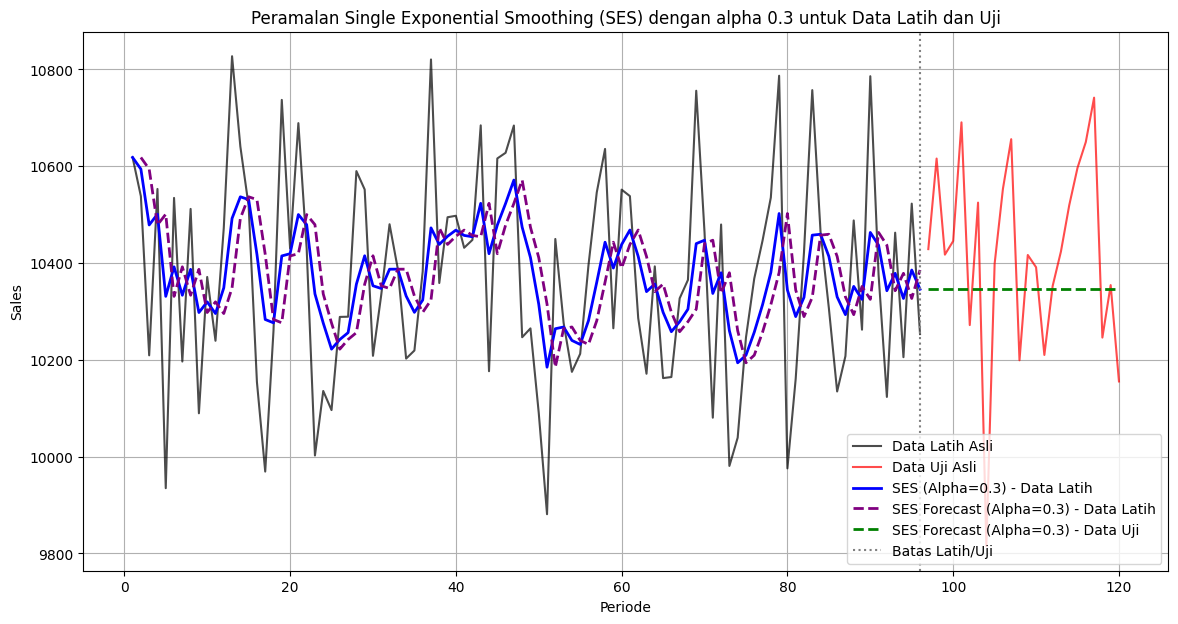

In [392]:
# 3. Peramalan untuk Data Latih (1-langkah ke depan)
# Peramalan untuk periode t+1 adalah nilai smoothed pada periode t
train_ses_forecast = train_data_ses['SES'].shift(1)

# 4. Peramalan untuk Data Uji (multi-langkah ke depan)
# Nilai peramalan untuk seluruh periode uji adalah nilai SES terakhir dari data latih
if not train_data_ses['SES'].empty:
    last_ses_from_train = train_data_ses['SES'].iloc[-1]
else:
    last_ses_from_train = np.nan

test_ses_forecast = pd.Series(last_ses_from_train, index=test_data_ses.index)

# 5. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_ses.Period, train_data_ses.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_ses.Period, test_data_ses.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot SES untuk data latih (nilai yang dihaluskan)
plt.plot(train_data_ses.Period[~train_data_ses['SES'].isnull()], train_data_ses['SES'][~train_data_ses['SES'].isnull()],
         label=f'SES (Alpha={alpha}) - Data Latih', color='blue', linestyle='-', linewidth=2)

# Plot nilai peramalan SES untuk data latih
plt.plot(train_data_ses.Period, train_ses_forecast,
         label=f'SES Forecast (Alpha={alpha}) - Data Latih', color='purple', linestyle='--', linewidth=2)

# Plot nilai peramalan SES untuk data uji
plt.plot(test_data_ses.Period, test_ses_forecast,
         label=f'SES Forecast (Alpha={alpha}) - Data Uji', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_ses.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Single Exponential Smoothing (SES) dengan alpha {alpha} untuk Data Latih dan Uji')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [393]:
# 6. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (SES) ---")
# Ambil data aktual dan peramalan yang tidak NaN (karena shift(1))
actual_train_ses_filtered = train_data_ses.loc[train_ses_forecast.dropna().index, 'Sales']
forecast_train_ses_filtered = train_ses_forecast.dropna()

if not actual_train_ses_filtered.empty and not forecast_train_ses_filtered.empty:
    mse_train_ses = mean_squared_error(actual_train_ses_filtered, forecast_train_ses_filtered)
    rmse_train_ses = calculate_rmse(actual_train_ses_filtered, forecast_train_ses_filtered)
    mape_train_ses = calculate_mape(actual_train_ses_filtered, forecast_train_ses_filtered)

    print(f"MSE (Train SES): {mse_train_ses:.4f}")
    print(f"RMSE (Train SES): {rmse_train_ses:.4f}")
    print(f"MAPE (Train SES): {mape_train_ses:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan SES.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (SES) ---")
actual_test_ses = test_data_ses['Sales']
forecast_test_ses = test_ses_forecast

if not actual_test_ses.empty and not forecast_test_ses.empty:
    mse_test_ses = mean_squared_error(actual_test_ses, forecast_test_ses)
    rmse_test_ses = calculate_rmse(actual_test_ses, forecast_test_ses)
    mape_test_ses = calculate_mape(actual_test_ses, forecast_test_ses)

    print(f"MSE (Test SES): {mse_test_ses:.4f}")
    print(f"RMSE (Test SES): {rmse_test_ses:.4f}")
    print(f"MAPE (Test SES): {mape_test_ses:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian SES.")


--- Evaluasi Peramalan Data Latih (SES) ---
MSE (Train SES): 58593.2500
RMSE (Train SES): 242.0604
MAPE (Train SES): 1.9040%

--- Evaluasi Peramalan Data Uji (SES) ---
MSE (Test SES): 46511.7955
RMSE (Test SES): 215.6659
MAPE (Test SES): 1.6498%


### Double Exponential Smoothing

Metode pemulusan *Double Exponential Smoothing* (DES) digunakan untuk data yang memiliki pola tren. Metode DES adalah metode semacam SES, hanya saja dilakukan dua kali, yaitu pertama untuk tahapan 'level' dan kedua untuk tahapan 'tren'. Pemulusan menggunakan metode ini akan menghasilkan peramalan tidak konstan untuk periode berikutnya.


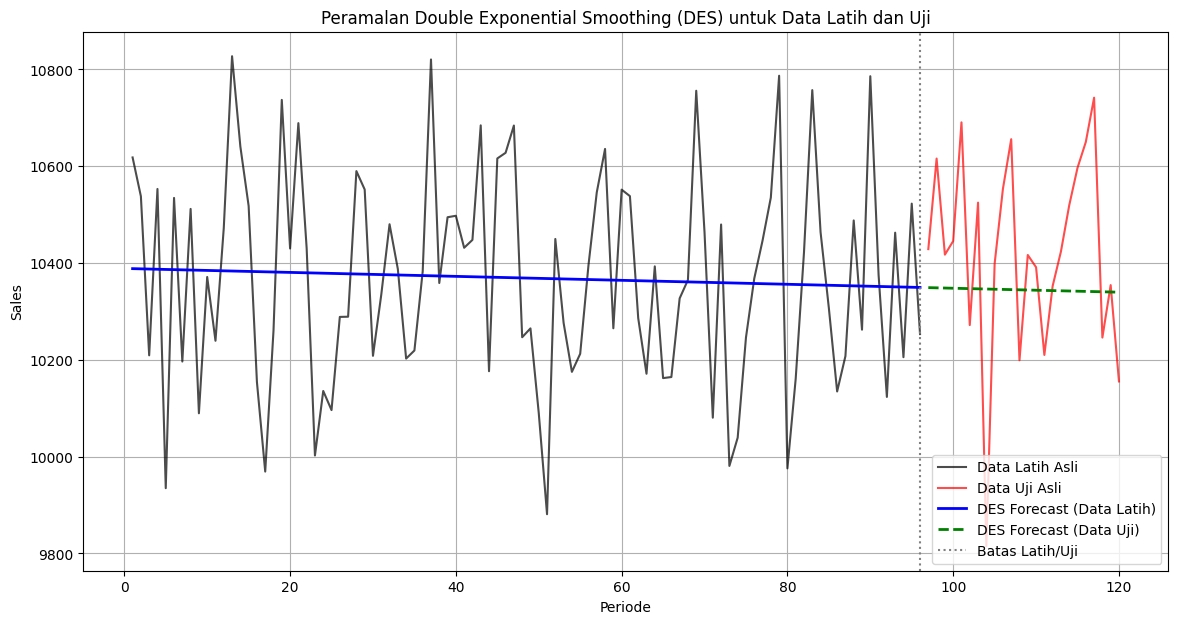

In [394]:
from statsmodels.tsa.api import ExponentialSmoothing

# 1. Membagi data menjadi data latih dan data uji untuk DES
# Menggunakan variabel train_size yang sudah didefinisikan sebelumnya
train_data_des = smoothing.iloc[:train_size].copy()
test_data_des = smoothing.iloc[train_size:].copy()

# 2. Lakukan Double Exponential Smoothing (DES) pada data latih
# model dengan trend='add' (additive trend) untuk Double Exponential Smoothing
# initialization_method='estimated' agar statsmodels mengestimasi parameter awal secara otomatis
model_des = ExponentialSmoothing(
    train_data_des['Sales'],
    trend='add',
    seasonal=None,
    seasonal_periods=None,
    initialization_method='estimated'
).fit()

# Dapatkan nilai peramalan in-sample (fitted values) untuk data latih
train_des_forecast = model_des.fittedvalues

# 3. Peramalan untuk Data Uji (multi-langkah ke depan)
# Menggunakan metode forecast() dari model yang sudah fit
test_des_forecast = model_des.forecast(len(test_data_des))

# 4. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_des.Period, train_data_des.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_des.Period, test_data_des.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot peramalan DES untuk data latih
plt.plot(train_data_des.Period, train_des_forecast,
         label='DES Forecast (Data Latih)', color='blue', linestyle='-', linewidth=2)

# Plot peramalan DES untuk data uji
plt.plot(test_data_des.Period, test_des_forecast,
         label='DES Forecast (Data Uji)', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_des.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title('Peramalan Double Exponential Smoothing (DES) untuk Data Latih dan Uji')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [395]:
# 5. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (DES) ---")
actual_train_des_filtered = train_data_des['Sales']
forecast_train_des_filtered = train_des_forecast

if not actual_train_des_filtered.empty and not forecast_train_des_filtered.empty:
    mse_train_des = mean_squared_error(actual_train_des_filtered, forecast_train_des_filtered)
    rmse_train_des = calculate_rmse(actual_train_des_filtered, forecast_train_des_filtered)
    mape_train_des = calculate_mape(actual_train_des_filtered, forecast_train_des_filtered)

    print(f"MSE (Train DES): {mse_train_des:.4f}")
    print(f"RMSE (Train DES): {rmse_train_des:.4f}")
    print(f"MAPE (Train DES): {mape_train_des:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan DES.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (DES) ---")
actual_test_des = test_data_des['Sales']
forecast_test_des = test_des_forecast

if not actual_test_des.empty and not forecast_test_des.empty:
    mse_test_des = mean_squared_error(actual_test_des, forecast_test_des)
    rmse_test_des = calculate_rmse(actual_test_des, forecast_test_des)
    mape_test_des = calculate_mape(actual_test_des, forecast_test_des)

    print(f"MSE (Test DES): {mse_test_des:.4f}")
    print(f"RMSE (Test DES): {rmse_test_des:.4f}")
    print(f"MAPE (Test DES): {mape_test_des:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian DES.")


--- Evaluasi Peramalan Data Latih (DES) ---
MSE (Train DES): 47689.8768
RMSE (Train DES): 218.3801
MAPE (Train DES): 1.7536%

--- Evaluasi Peramalan Data Uji (DES) ---
MSE (Test DES): 46667.5471
RMSE (Test DES): 216.0267
MAPE (Test DES): 1.6524%
